In [2]:
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from sklearn.model_selection import train_test_split

In [3]:
HAZY_PATH = "dataset/train/hazy"
GT_PATH = "dataset/train/GT"

In [4]:
IMG_SIZE = 128
LIMIT = None

In [5]:
tf.keras.backend.clear_session()

In [6]:
hazy_images = []
gt_images = []

hazy_files = sorted(os.listdir(HAZY_PATH))[:LIMIT]

for file in hazy_files:
    hazy_img_path = os.path.join(HAZY_PATH, file)
    gt_img_path = os.path.join(GT_PATH, file)

    if os.path.exists(gt_img_path):
        hazy = cv2.imread(hazy_img_path)
        gt = cv2.imread(gt_img_path)

        hazy = cv2.cvtColor(hazy, cv2.COLOR_BGR2RGB)
        gt = cv2.cvtColor(gt, cv2.COLOR_BGR2RGB)

        hazy = cv2.resize(hazy, (IMG_SIZE, IMG_SIZE))
        gt = cv2.resize(gt, (IMG_SIZE, IMG_SIZE))

        hazy = hazy.astype(np.float32) / 255.0
        gt = gt.astype(np.float32) / 255.0
        
        hazy_images.append(hazy)
        gt_images.append(gt)

hazy_images = np.array(hazy_images)
gt_images = np.array(gt_images)

print("Dataset loaded ", hazy_images.shape, gt_images.shape)

Dataset loaded  (6000, 128, 128, 3) (6000, 128, 128, 3)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    hazy_images, gt_images, test_size=0.2, random_state=42, shuffle=True
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (4800, 128, 128, 3)
Test: (1200, 128, 128, 3)


In [8]:
from keras import regularizers

In [9]:
from tensorflow.keras.applications import MobileNetV2

In [10]:

def build_transfer_unet():
    # Pretrained MobileNetV2
    base_model = MobileNetV2(
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
        include_top=False,
        weights='imagenet'
    )

    # Skip connection layers
    layer_names = [
        'block_1_expand_relu',   # 64x64
        'block_3_expand_relu',   # 32x32
        'block_6_expand_relu',   # 16x16
        'block_13_expand_relu',  # 8x8
        'block_16_project'       # 4x4
    ]

    skip_outputs = [base_model.get_layer(name).output for name in layer_names]

    # Encoder model
    down_stack = Model(inputs=base_model.input, outputs=skip_outputs)

    # Freeze pretrained layers initially
    down_stack.trainable = False

    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

    x_in = layers.Rescaling(2.0, offset=-1.0)(inputs)

    # Encoder outputs
    skips = down_stack(x_in)
    x = skips[-1]
    skips = reversed(skips[:-1])

    # Decoder
    up_filters = [512, 256, 128, 64]

    for up_filter, skip in zip(up_filters, skips):
        x = layers.UpSampling2D((2,2))(x)
        x = layers.Concatenate()([x, skip])
        
        x = layers.Conv2D(up_filter, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)
        x = layers.Conv2D(up_filter, 3, padding='same', activation='relu')(x)
        x = layers.BatchNormalization()(x)

    # Final upsample
    x = layers.UpSampling2D((2,2))(x)
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Conv2D(3, (1,1), activation='sigmoid')(x)

    model = Model(inputs, outputs)

    return model,down_stack

In [11]:
def combined_loss(y_true, y_pred):
    mae = tf.reduce_mean(tf.abs(y_true - y_pred))
    ssim = 1 - tf.reduce_mean(tf.image.ssim(y_true, y_pred, max_val=1.0))
    return 0.7 * mae + 0.3 * ssim

In [12]:
def psnr_metric(y_true, y_pred):
    return tf.image.psnr(y_true, y_pred, max_val=1.0)

In [13]:
model, encoder = build_transfer_unet()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [14]:
model.compile(optimizer='adam', loss=combined_loss, metrics=[tf.keras.metrics.MeanSquaredError(), psnr_metric])


In [15]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ functional          │ [(None, 64, 64,   │  1,841,984 │ rescaling[0][0]   │
│ (Functional)        │ 96), (None, 32,   │            │                   │
│                     │ 32, 144), (None,  │            │                   │
│                     │ 16, 16, 192),     │            │                   │
│                     │ (None, 8, 8,      │            │                   │
│                     │ 576), (None, 4,   │            │                   │
│                     │ 4, 320)]          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 8, 8, 320) │          0 │ functional[0][4]  │
│ (UpSampling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 8, 8, 896) │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │                   │            │ functional[0][3]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 8, 8, 512) │  4,129,280 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 8, 8, 512) │      2,048 │ conv2d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 8, 8, 512) │  2,359,808 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 8, 8, 512) │      2,048 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (UpSampling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 16, 16,    │          0 │ up_sampling2d_1[… │
│ (Concatenate)       │ 704)              │            │ functional[0][2]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 16,    │  1,622,272 │ concatenate_1[0]… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 16, 16,    │    590,080 │ batch_normalizat… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 16,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_2     │ (None, 32, 32,    │          0 │ batch_normalizat

 Total params: 11,344,323 (43.28 MB)

 Trainable params: 9,498,435 (36.23 MB)

 Non-trainable params: 1,845,888 (7.04 MB)

In [16]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [17]:
from keras.callbacks import EarlyStopping

In [18]:
checkpoint_path = "best_dehaze_model.keras"

In [19]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=5, min_lr=1e-6),
    ModelCheckpoint(checkpoint_path, monitor="val_loss", save_best_only=True)
]

In [20]:
history1= model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[callbacks]
)

Epoch 1/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 698s 2s/step - loss: 0.1315 - mean_squared_error: 0.0173 - psnr_metric: 19.0935 - val_loss: 0.1332 - val_mean_squared_error: 0.0213 - val_psnr_metric: 18.3091 - learning_rate: 0.0010
Epoch 2/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 644s 2s/step - loss: 0.1001 - mean_squared_error: 0.0106 - psnr_metric: 21.0036 - val_loss: 0.1330 - val_mean_squared_error: 0.0200 - val_psnr_metric: 18.0228 - learning_rate: 0.0010
Epoch 3/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 665s 2s/step - loss: 0.0933 - mean_squared_error: 0.0095 - psnr_metric: 21.4956 - val_loss: 0.0921 - val_mean_squared_error: 0.0097 - val_psnr_metric: 21.6680 - learning_rate: 0.0010
Epoch 4/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 688s 2s/step - loss: 0.0880 - mean_squared_error: 0.0086 - psnr_metric: 21.9481 - val_loss: 0.0888 - val_mean_squared_error: 0.0090 - val_psnr_metric: 21.7618 - learning_rate: 0.0010
Epoch 5/25
300/300 ━━━━━━━━━━━━━━━━━━━━ 699s 2s/step - loss: 0.0827 - mean_squared_error: 0.0076 - psnr_metr

In [21]:
# fine tuning the encoder model
encoder.trainable = True

for layer in encoder.layers[:-20]:
    layer.trainable = False
for layer in encoder.layers[-20:]:
    layer.trainable = True

In [22]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),   # IMPORTANT
    loss=combined_loss,
    metrics=[tf.keras.metrics.MeanSquaredError(), psnr_metric]
)

In [23]:
history2 = model.fit(
    X_train, y_train,
    epochs=15,  
    
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

Epoch 1/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 783s 3s/step - loss: 0.0544 - mean_squared_error: 0.0035 - psnr_metric: 25.5363 - val_loss: 0.0636 - val_mean_squared_error: 0.0051 - val_psnr_metric: 24.4380 - learning_rate: 1.0000e-05
Epoch 2/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 732s 2s/step - loss: 0.0520 - mean_squared_error: 0.0031 - psnr_metric: 25.9076 - val_loss: 0.0628 - val_mean_squared_error: 0.0050 - val_psnr_metric: 24.5123 - learning_rate: 1.0000e-05
Epoch 3/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 728s 2s/step - loss: 0.0516 - mean_squared_error: 0.0031 - psnr_metric: 25.9842 - val_loss: 0.0628 - val_mean_squared_error: 0.0050 - val_psnr_metric: 24.5309 - learning_rate: 1.0000e-05
Epoch 4/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 748s 2s/step - loss: 0.0512 - mean_squared_error: 0.0030 - psnr_metric: 26.0787 - val_loss: 0.0628 - val_mean_squared_error: 0.0050 - val_psnr_metric: 24.5214 - learning_rate: 1.0000e-05
Epoch 5/15
300/300 ━━━━━━━━━━━━━━━━━━━━ 710s 2s/step - loss: 0.0511 - mean_squared_error: 0.

In [24]:
res= model.evaluate(X_test, y_test)
print("Test Results:", res)


38/38 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - loss: 0.0624 - mean_squared_error: 0.0049 - psnr_metric: 24.5580
Test Results: [0.0623936764895916, 0.004905265290290117, 24.558029174804688]


In [25]:
predictions = model.predict(X_test)

38/38 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step


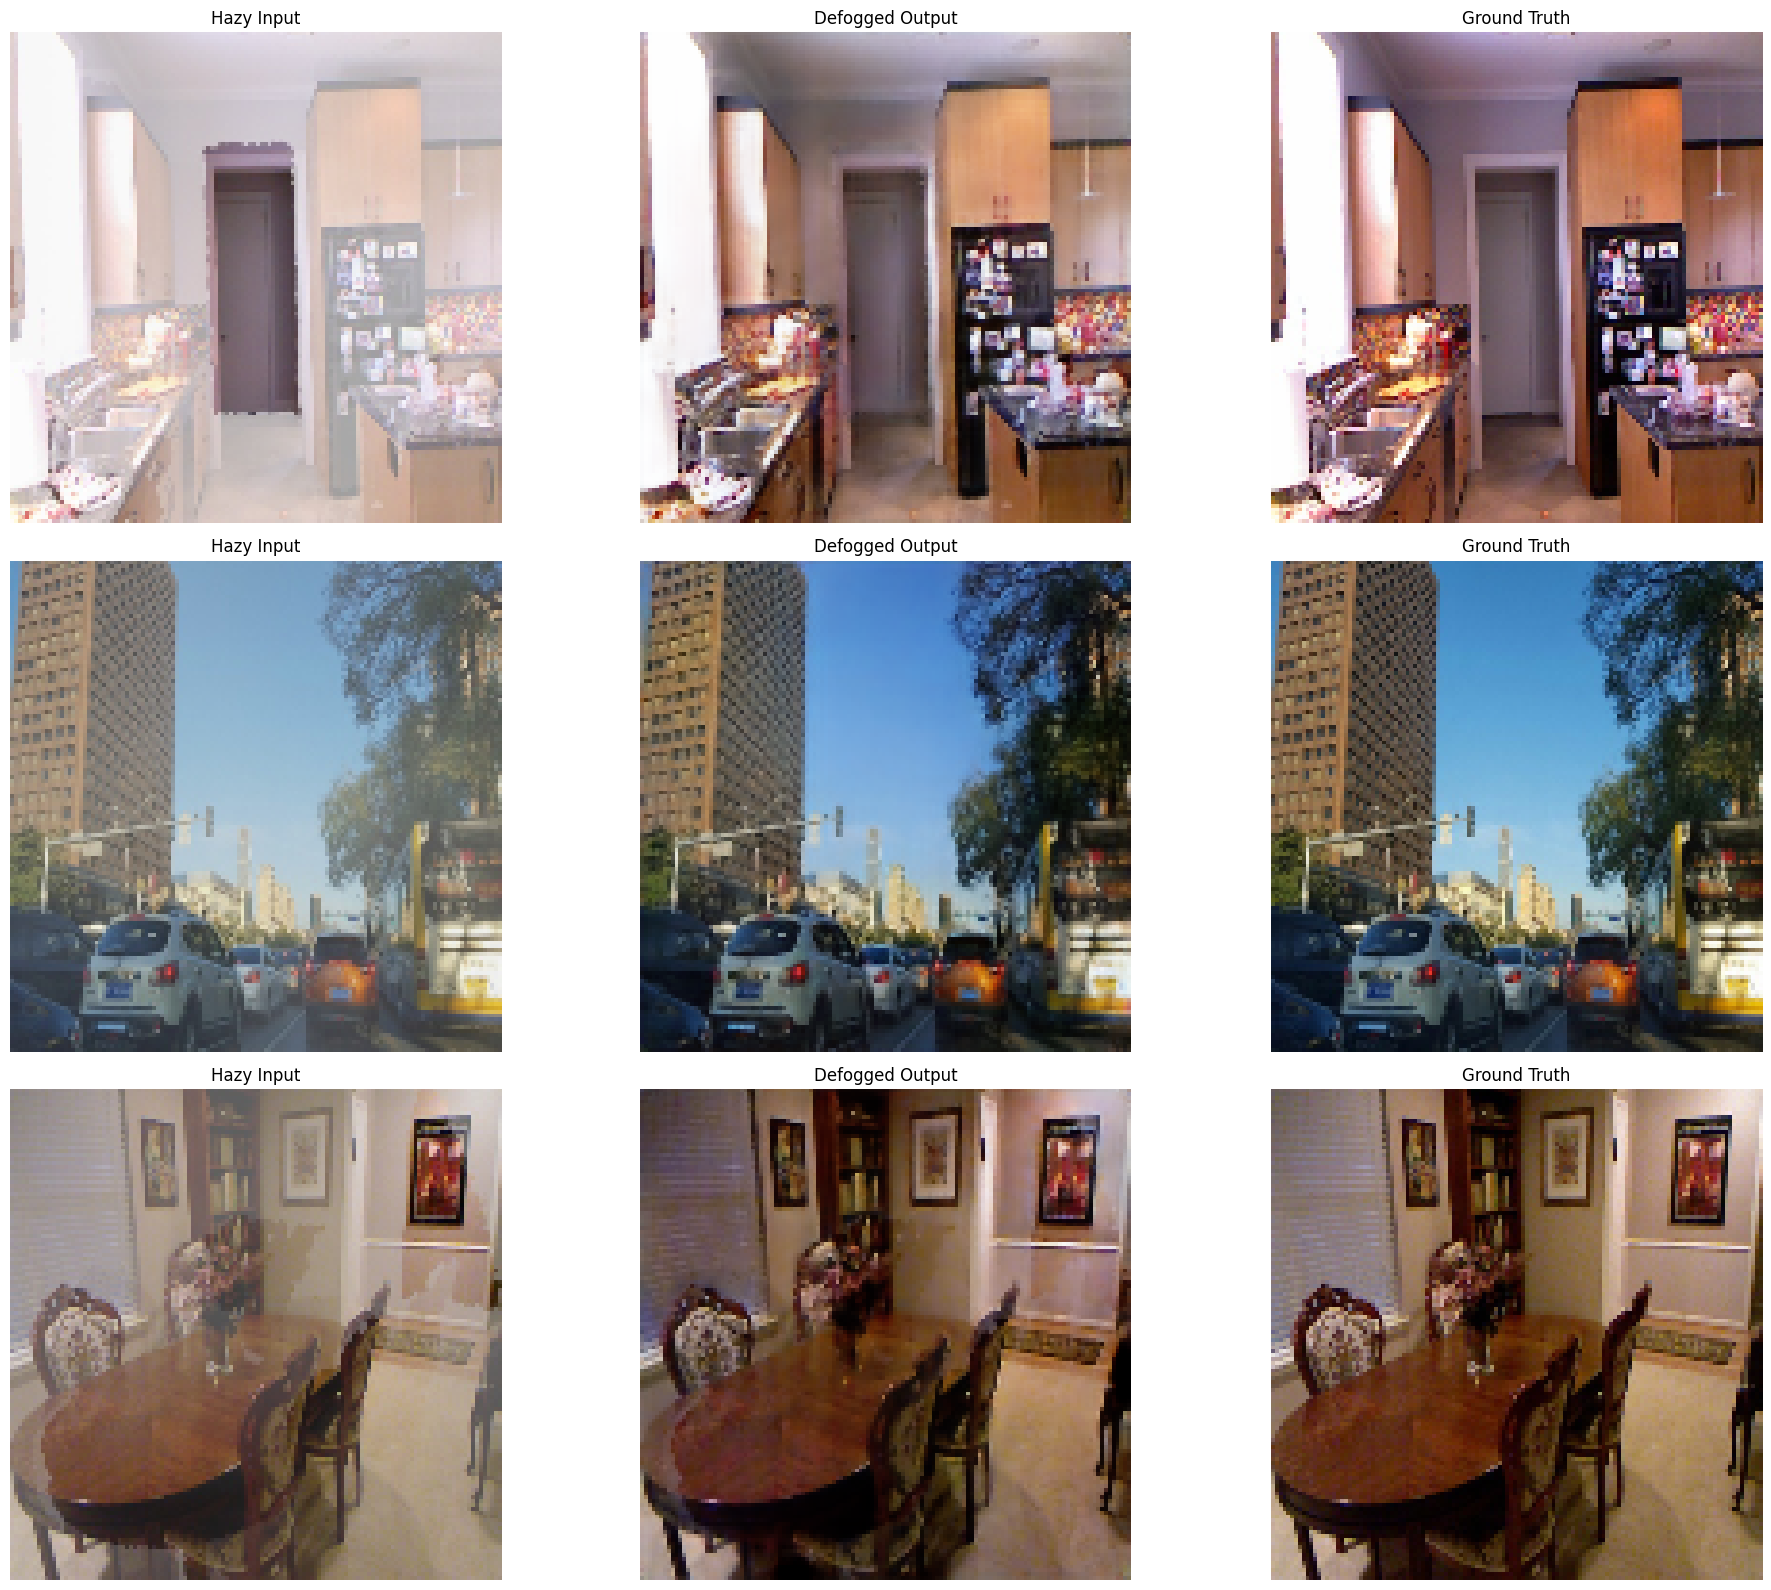

In [37]:
n = 3
plt.figure(figsize=(20, 16))

for i in range(n):
    # Hazy
    ax = plt.subplot(n, 3, i*3 + 1)
    plt.imshow(X_test[i+15])
    plt.title("Hazy Input")
    plt.axis("off")

    # Predicted
    ax = plt.subplot(n, 3, i*3 + 2)
    plt.imshow(predictions[i+15])
    plt.title("Defogged Output")
    plt.axis("off")

    # GT
    ax = plt.subplot(n, 3, i*3 + 3)
    plt.imshow(y_test[i+15])
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()

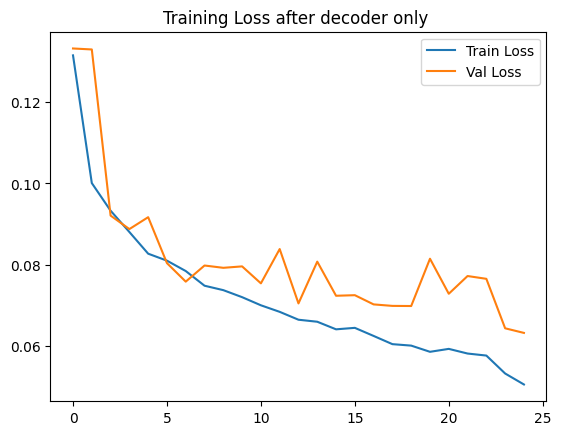

In [38]:
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training Loss after decoder only ")
plt.show()

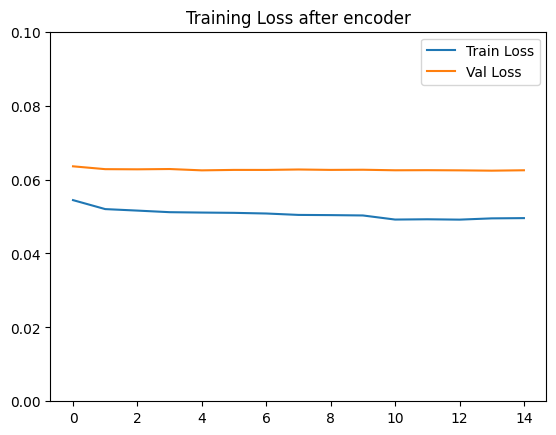

In [43]:
plt.plot(history2.history['loss'], label='Train Loss')
plt.plot(history2.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Training Loss after encoder")
plt.ylim(0, 0.1)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step


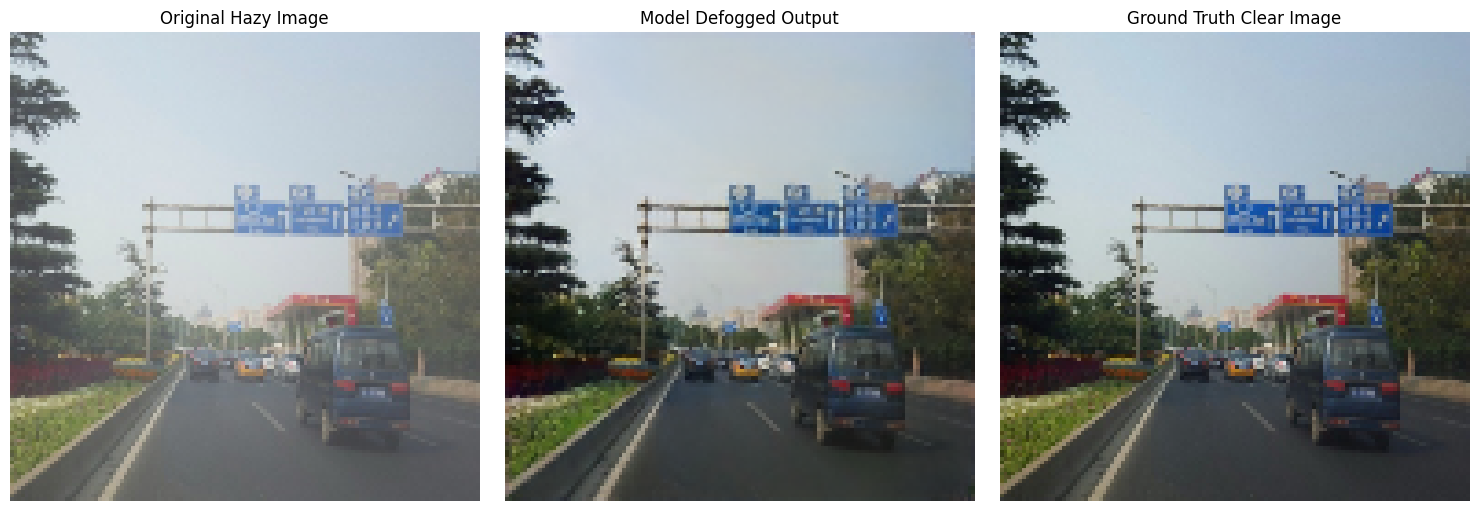

In [49]:
TRAIN_HAZY_PATH = "dataset/train/hazy"
TRAIN_GT_PATH = "dataset/train/GT"


sample_file = sorted(os.listdir(TRAIN_HAZY_PATH))[150]


hazy_img = cv2.imread(os.path.join(TRAIN_HAZY_PATH, sample_file))
hazy_img = cv2.cvtColor(hazy_img, cv2.COLOR_BGR2RGB)


gt_img = cv2.imread(os.path.join(TRAIN_GT_PATH, sample_file))
gt_img = cv2.cvtColor(gt_img, cv2.COLOR_BGR2RGB)


hazy_resized = cv2.resize(hazy_img, (IMG_SIZE, IMG_SIZE))
gt_resized = cv2.resize(gt_img, (IMG_SIZE, IMG_SIZE))

input_img = hazy_resized / 255.0
input_batch = np.expand_dims(input_img, axis=0)


predicted = model.predict(input_batch)[0]


plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(hazy_resized)
plt.title("Original Hazy Image")
plt.axis("off")


plt.subplot(1,3,2)
plt.imshow(predicted)
plt.title("Model Defogged Output")
plt.axis("off")


plt.subplot(1,3,3)
plt.imshow(gt_resized)
plt.title("Ground Truth Clear Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [50]:
model.save("final_dehaze_model.keras")